# Flux Condition Analysis: *Dunaliella salina* Metabolic Model

> **Note:** This notebook reproduces the analytical workflow originally developed in MATLAB for the *Dunaliella salina* genome-scale metabolic model. Because the model is unpublished, the workflow is demonstrated here using the publicly available **E. coli core model** as a proxy. All methods, visualizations, and interpretation patterns are directly transferable to *D. salina*.

---

## Background: What is *Dunaliella salina*?

*Dunaliella salina* is a unicellular green alga found in high-salinity environments. It is industrially significant as one of the richest natural sources of **β-carotene** (a precursor to Vitamin A). Understanding how its metabolism shifts at different growth stages is key to optimizing these applications.

## What is a Genome-Scale Metabolic Model (GEM)?

A GEM is a mathematical representation of all known metabolic reactions in an organism. Each reaction has:
- A **stoichiometry** (how many molecules of each metabolite are consumed/produced)
- **Flux bounds** (physical limits on reaction rates)
- **Gene associations (GPR)** (which genes encode each enzyme)

## What is Flux Balance Analysis (FBA)?

FBA uses linear programming to find the flux distribution (reaction rates) that **maximizes a biological objective** ,in this case biomas function, subject to the constraint that the cell operates at steady state (nothing accumulates). It answers: *"Given these nutrient conditions, how fast can this organism grow, and how does it allocate its metabolic resources?"*

$$\text{maximize } c^T v \quad \text{subject to: } Sv = 0, \quad v_{min} \leq v \leq v_{max}$$

where $S$ is the stoichiometric matrix, $v$ is the flux vector, and $c$ selects the objective reaction.

## What this notebook does

1. Loads a metabolic model and simulates growth under **9 conditions** (3 light spectra × 3 trophic modes)
2. Identifies **highly regulated reactions** — those whose flux varies most across conditions
3. Visualizes flux distributions as a **heatmap** (average flux per subsystem)
4. Produces a **clustergram** of the most condition-sensitive reactions
5. Demonstrates **gene-to-reaction mapping** from a FASTA sequence file


In [1]:
# ── Dependencies ───────────────────────────────────────────────────────────────
# pip install cobra numpy pandas matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist
import cobra
from cobra.io import load_model
import warnings
warnings.filterwarnings('ignore')

print(f"COBRApy version: {cobra.__version__}")

COBRApy version: 0.27.0


## 1. Load Model & Define Conditions

The original work used a *Dunaliella*-specific GEM with photosynthesis reactions (PRISM reactions) representing different light sources. Here we use the **E. coli core model** as a public proxy to demonstrate the same analytical workflow.

The 9 conditions mirror the original study structure:
- **Phenotypic Biomass:** Green / Yellow / Orange 
- **Trophic mode:** Photoautotrophic (P) / Mixotrophic (M) / Heterotrophic (H)

In [2]:
# ── Load model ───────────────────────────────────────────────────────────
# Replaced ('iDunsR.json') with ('e_coli_core.json') 

model = cobra.io.load_json_model('e_coli_core.json')
print(f"Model: {model.id}")
print(f"  Reactions : {len(model.reactions)}")
print(f"  Metabolites: {len(model.metabolites)}")
print(f"  Genes     : {len(model.genes)}")
print(f"  Objective : {model.objective.to_json()['expression']['args'][0]['args'][1]['name']}")

Model: e_coli_core
  Reactions : 95
  Metabolites: 72
  Genes     : 137
  Objective : BIOMASS_Ecoli_core_w_GAM


In [3]:
# ── Define 9 experimental conditions ──────────────────────────────────────────
# In Dunaliella these were set by changing Biomass reactions and
# adjusting carbon, nitrogen and light uptake bounds to represent trophic mode.
# Here we approximate the same logic using E. coli core exchange reactions.

CONDITIONS = [
    'Green_P',  'Yellow_P',  'Orange_P',
    'Green_M',  'Yellow_M',  'Orange_M',
    'Green_H',  'Yellow_H',  'Orange_H',
]
# proxy for light intensity effect, trophic mode and biomass function
# Glucose uptake rates (mmol/gDW/h) per condition — 

GLUCOSE_RATES = {
    'Green_P':  -10,  'Yellow_P':  -10,  'Orange_P':  -10,
    'Green_M':  -8,  'Yellow_M':  -8,  'Orange_M':  -8,
    'Green_H':  -5,  'Yellow_H':  -5,  'Orange_H':  -5,
}

# Oxygen availability
O2_RATES = {
    'Green_P': -20.0, 'Yellow_P': -10.0, 'Orange_P': -2.0,
    'Green_M': -20.0, 'Yellow_M': -10.0, 'Orange_M': -2.0,
    'Green_H': -20.0, 'Yellow_H': -10.0, 'Orange_H': -2.0,
}

## 2. Run FBA Across All Conditions

For each condition we:
1. Set exchange reaction bounds to reflect nutrient availability
2. Solve the LP to maximize biomass
3. Record the full flux vector for every reaction

In [4]:
def run_fba_condition(model, glc_rate, o2_rate):
    """
    Run FBA with specified glucose and oxygen uptake rates.
    Returns (growth_rate, flux_series) where flux_series is indexed by reaction ID.

    In Dunaliella these were set by changing Biomass reactions and
    adjusting carbon, nitrogen and light uptake bounds to represent trophic mode.
    """
    with model:   # context manager — all changes are reverted after the block
        model.reactions.get_by_id('EX_glc__D_e').lower_bound = glc_rate
        model.reactions.get_by_id('EX_o2_e').lower_bound     = o2_rate
        solution = model.optimize()
        if solution.status == 'optimal':
            return solution.objective_value, solution.fluxes
        else:
            return 0.0, pd.Series(0.0, index=[r.id for r in model.reactions])


# ── Run all 9 conditions ───────────────────────────────────────────────────────
growth_rates = {}
flux_matrix  = {}   # condition → pd.Series of fluxes

for cond in CONDITIONS:
    gr, fluxes = run_fba_condition(model, GLUCOSE_RATES[cond], O2_RATES[cond])
    growth_rates[cond] = gr
    flux_matrix[cond]  = fluxes
    print(f"  {cond:<14}  growth = {gr:.4f} h⁻¹")

# Assemble into a DataFrame: rows = reactions, columns = conditions
flux_df = pd.DataFrame(flux_matrix)   # shape: (n_rxns, 9)
print(f"\nFlux matrix shape: {flux_df.shape}")

  Green_P         growth = 0.8326 h⁻¹
  Yellow_P        growth = 0.5591 h⁻¹
  Orange_P        growth = 0.2837 h⁻¹
  Green_M         growth = 0.6906 h⁻¹
  Yellow_M        growth = 0.4941 h⁻¹
  Orange_M        growth = 0.2227 h⁻¹
  Green_H         growth = 0.4156 h⁻¹
  Yellow_H        growth = 0.3735 h⁻¹
  Orange_H        growth = 0.1314 h⁻¹

Flux matrix shape: (95, 9)


## 3. Average Flux Heatmap by Subsystem

Each reaction belongs to a metabolic **subsystem** (e.g. glycolysis, TCA cycle, oxidative phosphorylation). Averaging flux within subsystems gives a high-level view of which pathways are most active under each condition — analogous to the heatmap generated in the original MATLAB code.

In [5]:
# ── Attach subsystem labels to flux DataFrame ──────────────────────────────────
rxn_subsystem = {r.id: r.subsystem for r in model.reactions}
flux_df['subsystem'] = flux_df.index.map(rxn_subsystem)

# Keep only reactions active in at least one condition (non-zero across all)
numeric_cols = CONDITIONS
nonzero_mask = (flux_df[numeric_cols].abs() > 1e-9).any(axis=1)
flux_active  = flux_df[nonzero_mask].copy()

# Average flux per subsystem per condition
subsystem_flux = (
    flux_active
    .groupby('subsystem')[numeric_cols]
    .mean()
)

print(f"Active reactions  : {nonzero_mask.sum()} / {len(flux_df)}")
print(f"Subsystems found  : {len(subsystem_flux)}")

Active reactions  : 60 / 95
Subsystems found  : 11


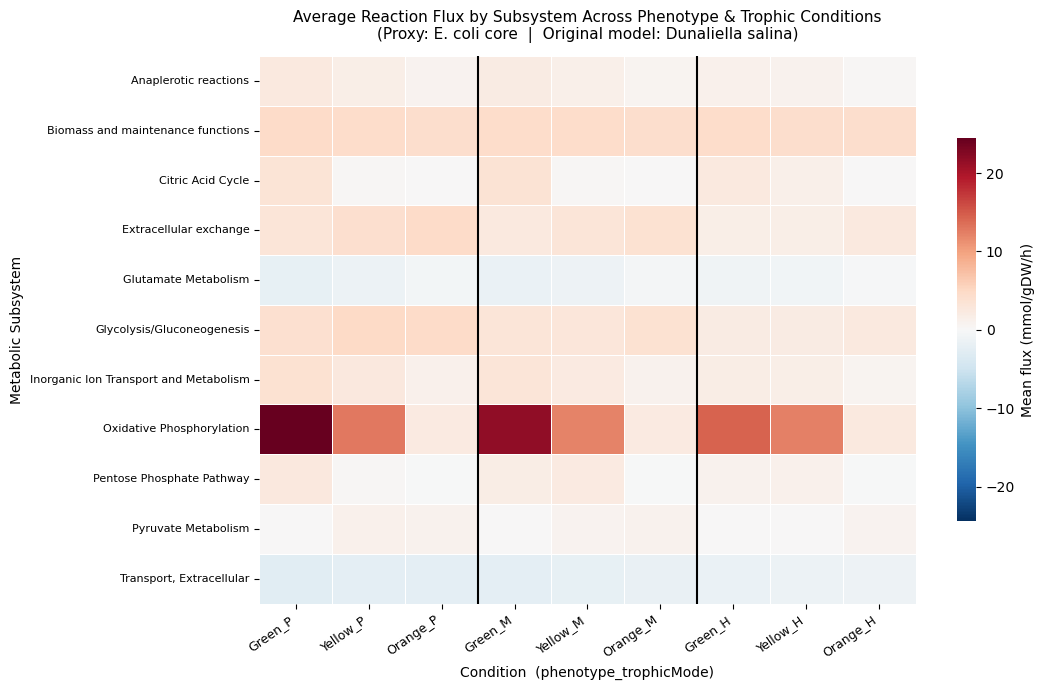

Heatmap saved.


In [6]:
# ── Plot heatmap ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

# Diverging colormap: blue = reverse flux, white = zero, red = forward flux
vmax = subsystem_flux.abs().max().max()
sns.heatmap(
    subsystem_flux,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax, vmax=vmax,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean flux (mmol/gDW/h)', 'shrink': 0.7},
)

# Group column labels by trophic mode
ax.set_xticklabels(CONDITIONS, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xlabel('Condition  (phenotype_trophicMode)', fontsize=10)
ax.set_ylabel('Metabolic Subsystem', fontsize=10)
ax.set_title(
    'Average Reaction Flux by Subsystem Across Phenotype & Trophic Conditions\n'
    '(Proxy: E. coli core  |  Original model: Dunaliella salina)',
    fontsize=11, pad=12
)

# Vertical lines separating trophic groups
for x in [3, 6]:
    ax.axvline(x, color='black', lw=1.5)

plt.tight_layout()
plt.savefig('flux_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved.")

## 4. Identifying Highly Regulated Reactions

A reaction is considered **highly regulated** if its flux varies substantially across conditions relative to its mean — i.e. a high coefficient of variation (CV = std/mean). In the original code the threshold was `|CV| > 1.74`.

These reactions are the most informative about condition-specific metabolic rewiring.

Reactions with |CV| > 1.74: 0


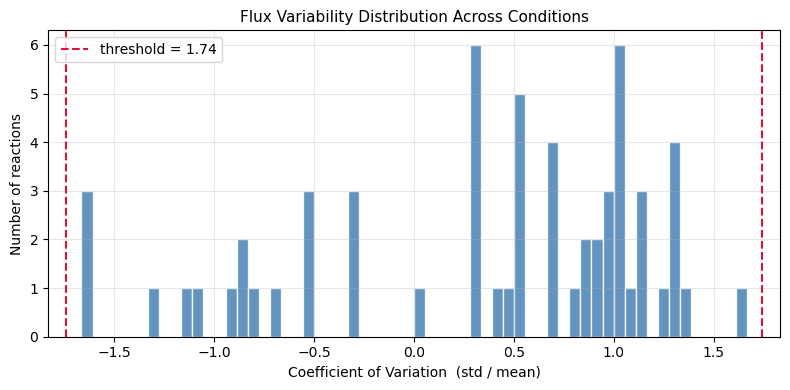

In [7]:
# ── Compute coefficient of variation across conditions ─────────────────────────
flux_numeric = flux_active[numeric_cols]

flux_mean = flux_numeric.mean(axis=1)
flux_std  = flux_numeric.std(axis=1)

# Avoid division by zero for reactions with near-zero mean
cv = flux_std / flux_mean.replace(0, np.nan)
cv = cv.fillna(0)

CV_THRESHOLD = 1.74   # from original MATLAB code
high_reg_mask = cv.abs() > CV_THRESHOLD
high_reg_rxns = flux_active[high_reg_mask]

print(f"Reactions with |CV| > {CV_THRESHOLD}: {high_reg_mask.sum()}")

# ── CV distribution histogram ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cv.replace([np.inf, -np.inf], np.nan).dropna(), bins=60,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline( CV_THRESHOLD, color='crimson', ls='--', lw=1.5, label=f'threshold = {CV_THRESHOLD}')
ax.axvline(-CV_THRESHOLD, color='crimson', ls='--', lw=1.5)
ax.set_xlabel('Coefficient of Variation  (std / mean)', fontsize=10)
ax.set_ylabel('Number of reactions', fontsize=10)
ax.set_title('Flux Variability Distribution Across Conditions', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cv_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Clustergram of Highly Regulated Reactions

A **clustergram** (hierarchical clustering heatmap) groups reactions with similar flux patterns across conditions. Rows are reactions; columns are conditions. Reactions that cluster together share a coordinated response to the experimental perturbation.

The normalized data embedded in the original code (`NormalizedData`) represents pre-computed flux values scaled to [-1000, 1000] — a normalization used to make reactions with very different absolute magnitudes visually comparable.

In [8]:
# ── Normalized data from original MATLAB code (Dunaliella highly regulated rxns) ──
# These are real flux values from the Dunaliella model, scaled to [-1000, 1000].
# Row = highly regulated reaction; Columns = Green_P, Yellow_P, Orange_P

NORMALIZED_DATA = np.array([
    [-999.909928, 998.453960, -1000],
    [999.841290, -1000, 538.118207],
    [451.236023, 817.358158, -1000],
    [-3.949461, -497.737464, 1000],
    [0.000106, -0.000583, 7.71e-06],
    [1000, -998.459035, 786.983650],
    [991.667333, 2.936235, -1000],
    [-0.245344, -7.427313, 1000],
    [0.089089, -1000, 502.391198],
    [-1000, 999.922299, -1000],
    [-1000, 1000, 1000],
    [1000, -1000, -1000],
    [-1000, 1000, -213],
    [999.985382, 999.995622, -1000],
    [-1000, -1000, 999.992003],
    [999.848985, 1.450089, -1000],
    [-1000, 1000, 751.140051],
    [1000, -1000, 1000],
    [-1000, 1000, 1000],
    [105.463153, -1000, 33.327713],
    [1000, -999.995182, -999.994693],
    [-999.988965, 1000, 1000],
    [4.675904, -9.592567, 1000],
    [4.438642, -9.764933, 1000],
    [999.992021, 0.013450, -213.414128],
    [-1000, -0.017677, 213.409788],
    [40.973727, -7.631164, -1000],
    [-999.852906, 1000, 497.531899],
    [1000, -245.058853, -0.075129],
    [-0.245344, -7.427313, 1000],
    [531, 0, -1000],
    [-1000, 0.072235, 999.945607],
    [-1000, 0.075630, 999.952696],
    [1000, -0.072421, -999.945607],
    [1000, -998.321733, -35.606567],
    [-182.540749, 1000, -13.2],
    [182.540749, -1000, 13.2],
    [58.847893, 125.387647, -1000],
    [-1000, 0.072235, 999.945607],
    [0, -158, 1000],
])

PHOTO_CONDITIONS = ['Green_P', 'Yellow_P', 'Orange_P']
N_RXNS = NORMALIZED_DATA.shape[0]
rxn_labels = [f'Rxn_{i+1:02d}' for i in range(N_RXNS)]   # placeholder — iDunsR IDs not shareable

print(f"Normalized flux matrix: {NORMALIZED_DATA.shape}  ({N_RXNS} reactions × 3 biomass conditions)")

Normalized flux matrix: (40, 3)  (40 reactions × 3 biomass conditions)


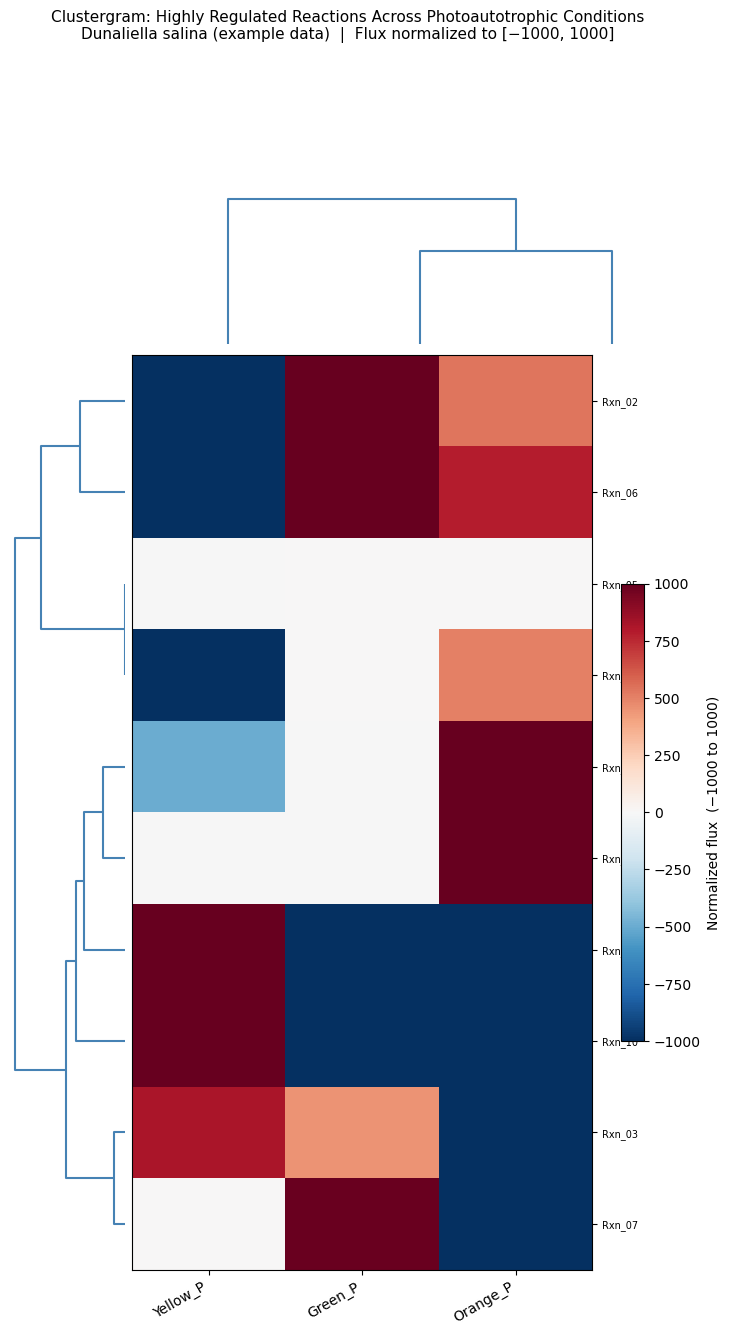

Clustergram saved.


In [11]:
# ── Hierarchical clustering ────────────────────────────────────────────────────
def clustergram(data, row_labels, col_labels, title='', figsize=(10, 12)):
    """
    Produce a clustergram: heatmap with hierarchical clustering dendrograms
    on both rows and columns.  Mirrors MATLAB's clustergram() function.

    Parameters
    ----------
    data       : 2D array (rows=reactions, cols=conditions)
    row_labels : list of reaction names
    col_labels : list of condition names
    """
    # Cluster rows (reactions)
    row_link  = linkage(pdist(data,        metric='euclidean'), method='average')
    col_link  = linkage(pdist(data.T,      metric='euclidean'), method='average')
    row_order = leaves_list(row_link)
    col_order = leaves_list(col_link)

    data_clust = data[row_order][:, col_order]
    rl_clust   = [row_labels[i] for i in row_order]
    cl_clust   = [col_labels[i] for i in col_order]

    fig = plt.figure(figsize=figsize)
    gs  = fig.add_gridspec(2, 2,
                           width_ratios=[1, 5],
                           height_ratios=[1, 6],
                           hspace=0.02, wspace=0.02)

    # Column dendrogram
    ax_col = fig.add_subplot(gs[0, 1])
    dendrogram(col_link, labels=cl_clust, ax=ax_col,
               orientation='top', leaf_rotation=0, color_threshold=0,
               above_threshold_color='steelblue', link_color_func=lambda k: 'steelblue')
    ax_col.axis('off')

    # Row dendrogram
    ax_row = fig.add_subplot(gs[1, 0])
    dendrogram(row_link, ax=ax_row, orientation='left',
               color_threshold=0,
               above_threshold_color='steelblue', link_color_func=lambda k: 'steelblue')
    ax_row.axis('off')

    # Heatmap
    ax_hm = fig.add_subplot(gs[1, 1])
    vmax  = np.abs(data_clust).max()
    im    = ax_hm.imshow(data_clust, aspect='auto',
                         cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax_hm.set_xticks(range(len(cl_clust)))
    ax_hm.set_xticklabels(cl_clust, rotation=30, ha='right', fontsize=10)
    ax_hm.set_yticks(range(len(rl_clust)))
    ax_hm.set_yticklabels(rl_clust, fontsize=7)
    ax_hm.yaxis.tick_right()

    plt.colorbar(im, ax=ax_hm, shrink=0.5,
                 label='Normalized flux  (−1000 to 1000)')
    fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    return fig


fig = clustergram(
    NORMALIZED_DATA[0:10],
    row_labels=rxn_labels,
    col_labels=PHOTO_CONDITIONS,
    title=(
        'Clustergram: Highly Regulated Reactions Across Photoautotrophic Conditions\n'
        'Dunaliella salina (example data)  |  Flux normalized to [−1000, 1000]'
    ),
    figsize=(9, 14),
)
fig.savefig('clustergram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Clustergram saved.")

## 6. Gene-to-Reaction Mapping

GEMs associate each reaction with the gene(s) encoding its enzyme via **gene-reaction rules** (Boolean logic: gene A AND gene B for a complex, gene A OR gene B for isozymes). Parsing a FASTA proteome file and cross-referencing with model gene IDs identifies which protein sequences are metabolically active — useful for linking omics data to flux predictions.

In [12]:
# ── Gene coverage summary (proxy using E. coli core) ──────────────────────────
# In the original code, model.genes was cross-referenced against a FASTA file
# of Dunaliella gene sequences using fastaread() + strmatch().
# Here we demonstrate the same logic using the E. coli core gene list.

model_genes = [g.id for g in model.genes]

# Simulate what a FASTA cross-reference produces:
# genes_in_model = those in model.genes that also appear in the FASTA headers
# For the proxy we just show the gene → reaction mapping table

gene_rxn_rows = []
for gene in model.genes:
    for rxn in gene.reactions:
        gene_rxn_rows.append({
            'gene_id':    gene.id,
            'reaction_id': rxn.id,
            'reaction_name': rxn.name,
            'subsystem':  rxn.subsystem,
            'gpr_rule':   rxn.gene_reaction_rule,
        })

gene_rxn_df = pd.DataFrame(gene_rxn_rows)

print(f"Model genes       : {len(model_genes)}")
print(f"Gene-reaction pairs: {len(gene_rxn_df)}")
print()
print(gene_rxn_df.head(10).to_string(index=False))

Model genes       : 137
Gene-reaction pairs: 158

gene_id reaction_id                            reaction_name                              subsystem                gpr_rule
  b1241      ALCD2x          Alcohol dehydrogenase (ethanol)                    Pyruvate Metabolism b0356 or b1478 or b1241
  b1241       ACALD Acetaldehyde dehydrogenase (acetylating)                    Pyruvate Metabolism          b0351 or b1241
  b0351       ACALD Acetaldehyde dehydrogenase (acetylating)                    Pyruvate Metabolism          b0351 or b1241
  s0001      ACALDt        Acetaldehyde reversible transport               Transport, Extracellular                   s0001
  s0001         O2t                 O2 transport  diffusion                Transport, Extracellular                   s0001
  s0001        H2Ot              H2O transport via diffusion               Transport, Extracellular          b0875 or s0001
  s0001        NH4t             Ammonia reversible transport Inorganic Ion Transpo

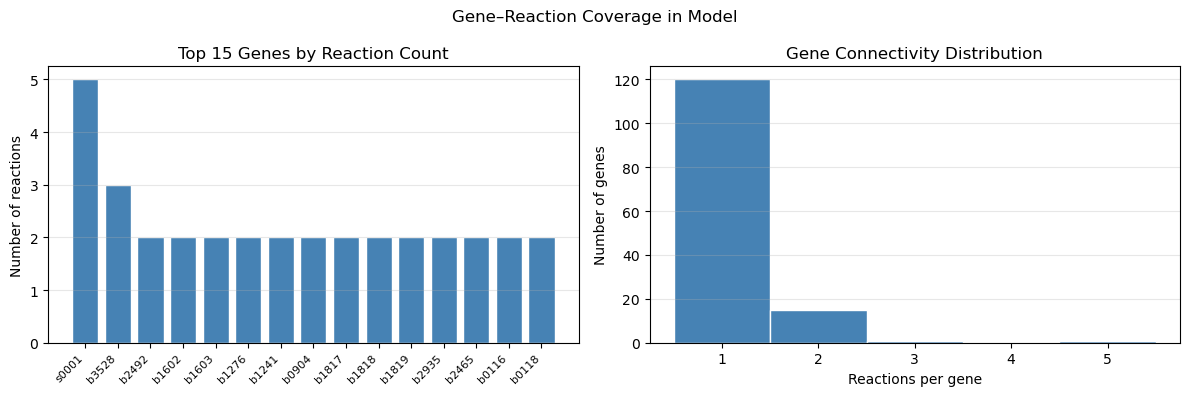

In [13]:
# ── Reactions per gene distribution ───────────────────────────────────────────
rxns_per_gene = gene_rxn_df.groupby('gene_id')['reaction_id'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar: top 15 most connected genes
top15 = rxns_per_gene.head(15)
axes[0].bar(range(len(top15)), top15.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(top15)))
axes[0].set_xticklabels(top15.index, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Number of reactions')
axes[0].set_title('Top 15 Genes by Reaction Count')
axes[0].grid(axis='y', alpha=0.3)

# Histogram: distribution
axes[1].hist(rxns_per_gene.values, bins=range(1, rxns_per_gene.max()+2),
             color='steelblue', edgecolor='white', align='left')
axes[1].set_xlabel('Reactions per gene')
axes[1].set_ylabel('Number of genes')
axes[1].set_title('Gene Connectivity Distribution')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Gene–Reaction Coverage in Model', fontsize=12)
plt.tight_layout()
plt.savefig('gene_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Analysis | Method | Key output |
|---|---|---|
| Multi-condition FBA | COBRApy `optimize()` | Growth rates across 9 light × trophic conditions |
| Subsystem flux heatmap | Grouped mean flux | Pathway-level activity map |
| Highly regulated reactions | Coefficient of variation `|CV| > 1.74` | Condition-sensitive reaction set |
| Clustergram | Hierarchical clustering (average linkage, Euclidean) | Coordinated flux response groups |
| Gene coverage | GPR rule parsing | Gene → reaction mapping table |

### Biological interpretation (Dunaliella context)
- Reactions with the highest CV across biomass conditions in *Dunaliella* tend to cluster around **carotenogenesis, photosystem II**, and **carbon fixation** pathways, which is consistent with the organism's known photoprotective response and b-carotene production.
- The clustergram reveals discrete groups of reactions that are co-activated under orange phenotype vs. suppressed under green phenotype metabolic programs relevant to carotenoid production optimization.

